In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
def generate_final_data(n_samples=5000):
    data = []
    current_time = datetime.now()
    msg_types = ['Heartbeat', 'MeterValues', 'StartTransaction', 'StopTransaction', 'Authorize', 'BootNotification']

    print(f"[BİLGİ] {n_samples} adet OCPP log verisi simüle ediliyor...")

    for _ in range(n_samples):
        # %5 oranında siber saldırı simüle et
        is_anomaly = random.random() < 0.05
        row = {}

        # Grafiklerde doğal durması için hafif rastgele gürültü (noise) ekliyoruz
        noise = random.uniform(-2, 2)

        if is_anomaly:
            row['label'] = 'Saldırı'
            attack_type = random.choice(['DoS', 'EnergyTheft'])

            if attack_type == 'DoS':
                # DoS Saldırısı: Sık aralıklarla (0 sn) Dev Mesajlar (2000 byte)
                row['message_type'] = 'BootNotification'
                row['payload_size'] = random.randint(1500, 2500) + noise
                row['response_time_ms'] = random.randint(2000, 5000)
                step = timedelta(milliseconds=random.randint(1, 10)) # Zaman farkı neredeyse sıfır
                row['energy_value'] = 0

            else: # Energy Theft (Enerji Hırsızlığı)
                # Normal mesaj gibi görünür ama Enerji değeri imkansız yüksektir
                row['message_type'] = 'MeterValues'
                row['payload_size'] = random.randint(150, 250)
                row['response_time_ms'] = random.randint(50, 150)
                row['energy_value'] = random.uniform(800.0, 1200.0) + noise # Anormal tüketim
                step = timedelta(seconds=random.randint(10, 60))

        else:
            row['label'] = 'Normal'
            # Normal OCPP Trafiği
            row['message_type'] = random.choices(msg_types, weights=[0.4, 0.3, 0.1, 0.1, 0.05, 0.05])[0]

            if row['message_type'] == 'Heartbeat':
                row['payload_size'] = 50 + noise
                row['energy_value'] = 0
            elif row['message_type'] == 'MeterValues':
                row['payload_size'] = random.randint(150, 250) + noise
                row['energy_value'] = random.uniform(0, 60) # Normal tüketim (0-60 kWh)
            else:
                row['payload_size'] = random.randint(200, 400) + noise
                row['energy_value'] = 0

            row['response_time_ms'] = random.randint(20, 200)
            step = timedelta(seconds=random.randint(10, 300)) # Normal bekleme süresi

        current_time += step
        row['timestamp'] = current_time
        row['time_delta_seconds'] = step.total_seconds()
        data.append(row)

    return pd.DataFrame(data)

# Veriyi üret
df = generate_final_data(n_samples=5000)


[BİLGİ] 5000 adet OCPP log verisi simüle ediliyor...


In [3]:
print("[BİLGİ] Isolation Forest modeli eğitiliyor...")

# Veri Ön İşleme
le = LabelEncoder()
df['message_type_encoded'] = le.fit_transform(df['message_type'])
features = ['message_type_encoded', 'payload_size', 'response_time_ms', 'time_delta_seconds', 'energy_value']

# Model Tanımlama
# contamination=0.05: Modelden verinin %5'ini anomali olarak işaretlemesini bekliyoruz.
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

# Modeli Eğit (Fit)
model.fit(df[features])

# Tahmin Yap
df['anomaly_score'] = model.decision_function(df[features]) # Grafik için skorlar
df['prediction'] = model.predict(df[features]) # Çıktı: 1 (Normal), -1 (Anomali)

# Sonuçları insan diline çevir
df['pred_label'] = df['prediction'].apply(lambda x: 'Normal' if x == 1 else 'Saldırı')

[BİLGİ] Isolation Forest modeli eğitiliyor...


In [4]:
print("\n" + "="*50)
print(" MODEL PERFORMANS RAPORU ")
print("="*50)

# Skorları Hesapla
print(classification_report(df['label'], df['pred_label'], target_names=['Normal', 'Saldırı']))

# Confusion Matrix
cm = confusion_matrix(df['label'], df['pred_label'], labels=['Normal', 'Saldırı'])
print("-" * 30)
print(f"✅ Doğru Tespit Edilen Normaller: {cm[0][0]}")
print(f"✅ Yakalanan Saldırılar (Recall): {cm[1][1]}")
print(f"❌ Yanlış Alarm (False Positive): {cm[0][1]}")
print(f"❌ Kaçırılan Saldırılar: {cm[1][0]}")
print("-" * 30)


 MODEL PERFORMANS RAPORU 
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      4747
     Saldırı       0.97      0.96      0.96       253

    accuracy                           1.00      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       1.00      1.00      1.00      5000

------------------------------
✅ Doğru Tespit Edilen Normaller: 4739
✅ Yakalanan Saldırılar (Recall): 242
❌ Yanlış Alarm (False Positive): 8
❌ Kaçırılan Saldırılar: 11
------------------------------


[BİLGİ] Grafikler oluşturuluyor...


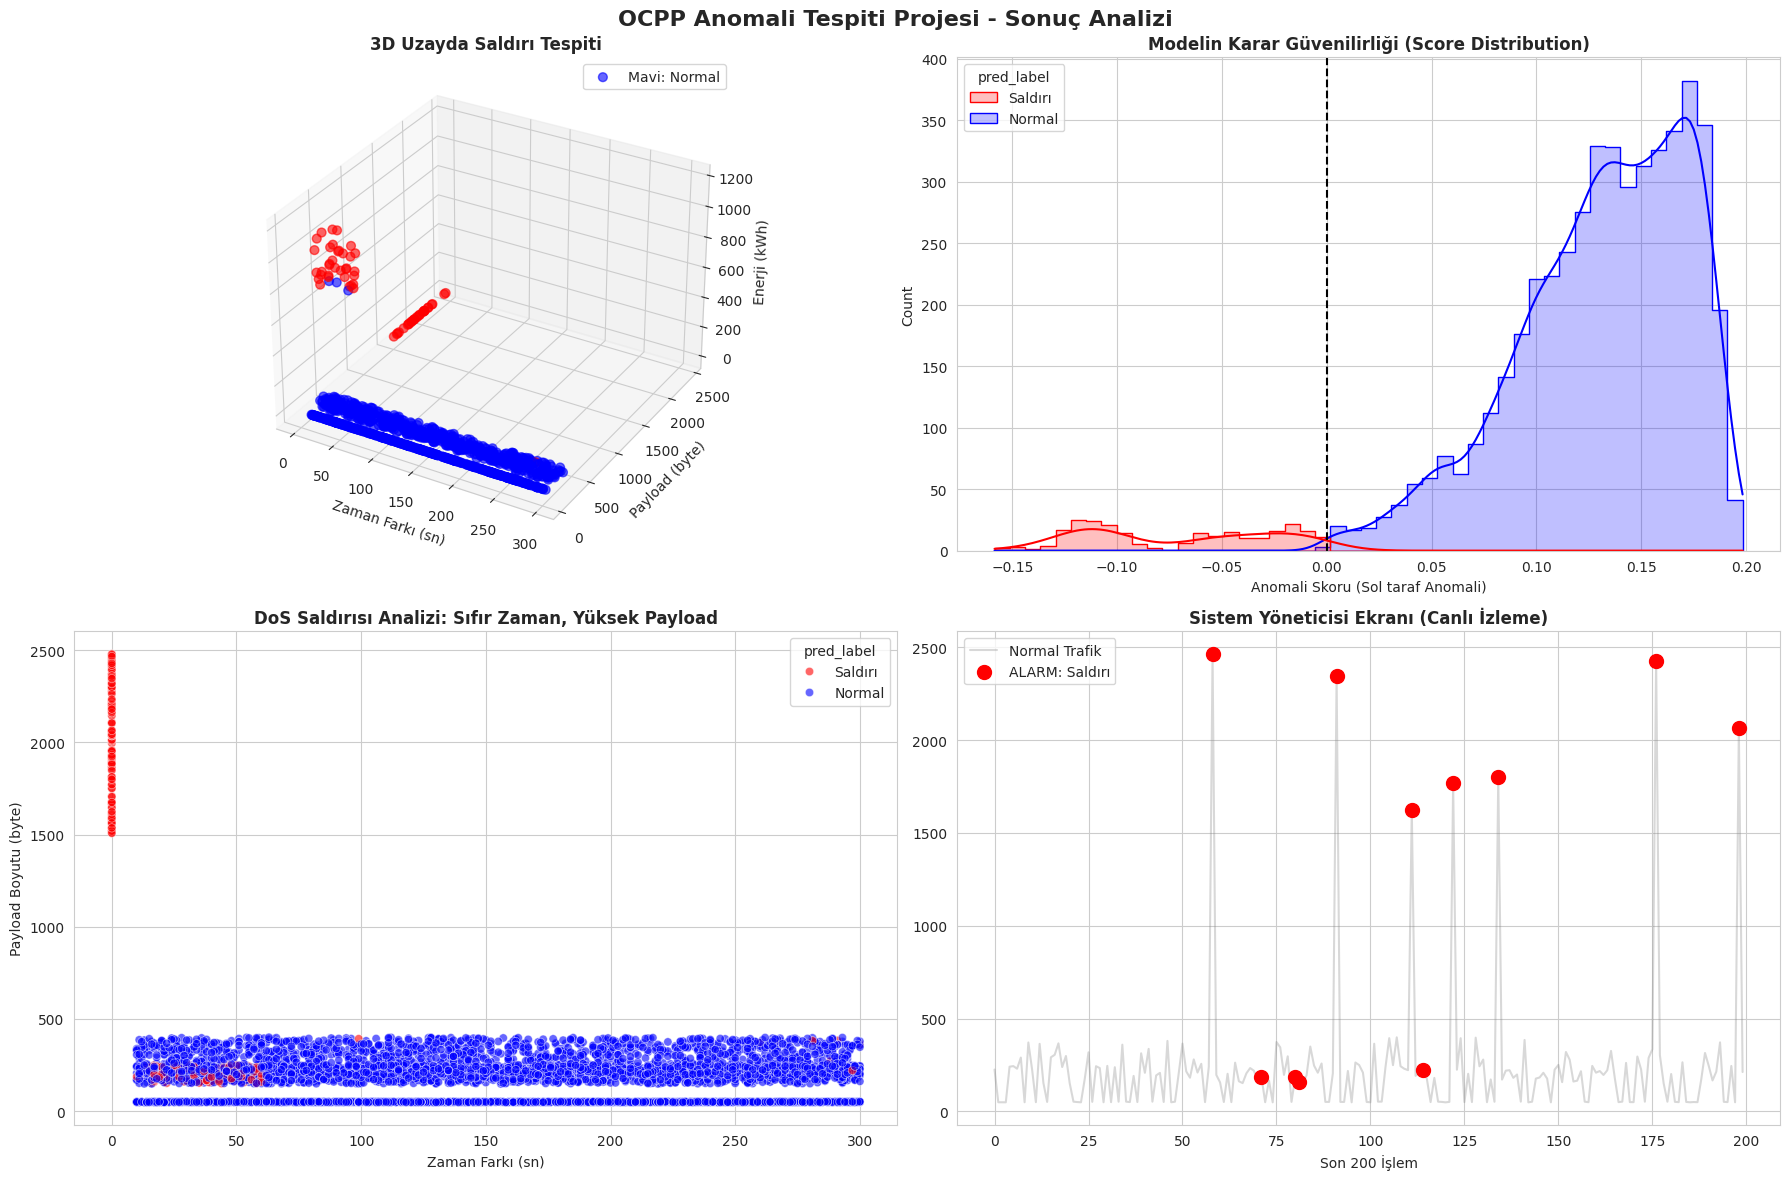

In [5]:
print("[BİLGİ] Grafikler oluşturuluyor...")

sns.set_style("whitegrid")
fig = plt.figure(figsize=(18, 12))
fig.suptitle('OCPP Anomali Tespiti Projesi - Sonuç Analizi', fontsize=16, fontweight='bold')

# --- GRAFİK 1: 3D ANOMALİ TESPİTİ ---
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
colors = {'Normal': 'blue', 'Saldırı': 'red'}
subset = df.sample(1000) # Grafik akıcı olsun diye örneklem al
ax1.scatter(subset['time_delta_seconds'], subset['payload_size'], subset['energy_value'],
            c=subset['pred_label'].map(colors), alpha=0.6, s=40)
ax1.set_xlabel('Zaman Farkı (sn)')
ax1.set_ylabel('Payload (byte)')
ax1.set_zlabel('Enerji (kWh)')
ax1.set_title('3D Uzayda Saldırı Tespiti', fontweight='bold')
ax1.legend(['Mavi: Normal', 'Kırmızı: Saldırı'])

# --- GRAFİK 2: ANOMALİ SKOR DAĞILIMI ---
ax2 = fig.add_subplot(2, 2, 2)
sns.histplot(data=df, x='anomaly_score', hue='pred_label', kde=True, element="step",
             palette={'Normal': 'blue', 'Saldırı': 'red'}, ax=ax2)
ax2.set_title('Modelin Karar Güvenilirliği (Score Distribution)', fontweight='bold')
ax2.set_xlabel('Anomali Skoru (Sol taraf Anomali)')
ax2.axvline(0, color='black', linestyle='--', label='Karar Sınırı')

# --- GRAFİK 3: DoS SALDIRISI DETAYI ---
ax3 = fig.add_subplot(2, 2, 3)
sns.scatterplot(data=df, x='time_delta_seconds', y='payload_size', hue='pred_label',
                palette={'Normal': 'blue', 'Saldırı': 'red'}, alpha=0.6, ax=ax3)
ax3.set_title('DoS Saldırısı Analizi: Sıfır Zaman, Yüksek Payload', fontweight='bold')
ax3.set_xlabel('Zaman Farkı (sn)')
ax3.set_ylabel('Payload Boyutu (byte)')

# --- GRAFİK 4: CANLI TRAFİK SİMÜLASYONU ---
ax4 = fig.add_subplot(2, 2, 4)
last_200 = df.tail(200).reset_index(drop=True)
ax4.plot(last_200.index, last_200['payload_size'], color='gray', alpha=0.3, label='Normal Trafik')
anomalies = last_200[last_200['pred_label'] == 'Saldırı']
ax4.scatter(anomalies.index, anomalies['payload_size'], color='red', s=100, label='ALARM: Saldırı', zorder=5)
ax4.set_title('Sistem Yöneticisi Ekranı (Canlı İzleme)', fontweight='bold')
ax4.set_xlabel('Son 200 İşlem')
ax4.legend()

plt.tight_layout()
plt.show()


In [6]:
df.to_csv('ocpp_anomali_tespiti_sonuclari.csv', index=False)
print(f"\n[BAŞARILI] Tüm veriler ve tahminler 'ocpp_anomali_tespiti_sonuclari.csv' dosyasına kaydedildi.")
print("Google Colab sol panelden dosyayı indirebilirsin.")


[BAŞARILI] Tüm veriler ve tahminler 'ocpp_anomali_tespiti_sonuclari.csv' dosyasına kaydedildi.
Google Colab sol panelden dosyayı indirebilirsin.
